In [143]:
# pip install

In [144]:
import requests
import pandas as pd
from io import StringIO
import geopandas as gpd
from shapely.geometry import Point
import geopandas as gpd
import rasterio as rio
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [145]:
url = "https://www.waterqualitydata.us/data/Result/search"

params = {
    "bBox": "-80.65,24.85,-80.20,25.35",
    "siteType": "Estuary",
    "startDateLo": "01-01-2015",
    "startDateHi": "12-31-2024",
    "sampleMedia": "Water",
    "characteristicName": [
        "Turbidity",
        "Salinity",
        "Temperature, water",
        "Chlorophyll a",
        "Depth, Secchi disk depth"
    ],
    "mimeType": "csv"
}

print("Downloading Upper Keys water quality results...")
response = requests.get(url, params=params)
print(f"Status: {response.status_code}")

if response.status_code == 200:
    df_wq = pd.read_csv(StringIO(response.text))
    print(f"Total rows: {df_wq.shape[0]}")
    print(f"Columns: {df_wq.columns.tolist()}")
    print(df_wq.head())
    
    # Save
    df_wq.to_csv("upper_keys_results.csv", index=False)
    print("Saved as upper_keys_results.csv")
else:
    print(f"Error: {response.text[:500]}")

Status: 200
Total rows: 8056
Columns: ['OrganizationIdentifier', 'OrganizationFormalName', 'ActivityIdentifier', 'ActivityTypeCode', 'ActivityMediaName', 'ActivityMediaSubdivisionName', 'ActivityStartDate', 'ActivityStartTime/Time', 'ActivityStartTime/TimeZoneCode', 'ActivityEndDate', 'ActivityEndTime/Time', 'ActivityEndTime/TimeZoneCode', 'ActivityDepthHeightMeasure/MeasureValue', 'ActivityDepthHeightMeasure/MeasureUnitCode', 'ActivityDepthAltitudeReferencePointText', 'ActivityTopDepthHeightMeasure/MeasureValue', 'ActivityTopDepthHeightMeasure/MeasureUnitCode', 'ActivityBottomDepthHeightMeasure/MeasureValue', 'ActivityBottomDepthHeightMeasure/MeasureUnitCode', 'ProjectIdentifier', 'ActivityConductingOrganizationText', 'MonitoringLocationIdentifier', 'ActivityCommentText', 'SampleAquifer', 'HydrologicCondition', 'HydrologicEvent', 'SampleCollectionMethod/MethodIdentifier', 'SampleCollectionMethod/MethodIdentifierContext', 'SampleCollectionMethod/MethodName', 'SampleCollectionEquipmentN

In [146]:
display(df_wq.head())

,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,ResultAnalyticalMethod/MethodName,MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,PreparationStartDate,ProviderName
0,21FLWQA_WQX,FDEP Watershed Assessment Section (WAS),21FLWQA_WQX-G5AA0008-11/23/20,Sample-Routine,Water,Surface Water,2020-11-23,13:16:00,EST,2020-11-23,...,Turbidity by Nephelometry,https://www.nemi.gov/methods/method_summary/5217/,E31780,2020-11-24,NaN,Practical Quantitation Limit,0.13,NTU,NaN,STORET
1,21FLDADE_WQX,Dade Environmental Resource Management (Florida),21FLDADE_WQX-BB48-0720S,Field Msr/Obs,Water,Surface Water,2020-07-22,09:19:00,EDT,NaN,...,FDEP FT1300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
2,21FLSFWM_WQX,South Florida Water Management District,21FLSFWM_WQX-P118758-7F,Field Msr/Obs,Water,Surface Water,2020-11-12,11:36:00,EDT,NaN,...,SFWMD FSQM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
3,21FLDADE_WQX,Dade Environmental Resource Management (Florida),21FLDADE_WQX-BB47-0120YB,Field Msr/Obs,Water,Surface Water,2020-01-08,09:07:00,EDT,NaN,...,FDEP FT1400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
4,21FLSFWM_WQX,South Florida Water Management District,21FLSFWM_WQX-P111062-6F,Field Msr/Obs,Water,Surface Water,2020-08-17,10:19:00,EDT,NaN,...,SFWMD FSQM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET


In [147]:
# Extract units per characteristic
units = (
    df_wq.groupby("CharacteristicName")["ResultMeasure/MeasureUnitCode"]
    .agg(lambda x: x.dropna().mode()[0] if x.dropna().any() else "")
    .to_dict()
)
print("Units found:", units)

# Build rename map with units
rename_map = {
    "Temperature, water":       f"Temperature ({units.get('Temperature, water', '°C')})",
    "Depth, Secchi disk depth": f"Secchi Depth ({units.get('Depth, Secchi disk depth', 'm')})",
    "Chlorophyll a":            f"Chlorophyll_a ({units.get('Chlorophyll a', 'µg/L')})",
    "Turbidity":                f"Turbidity ({units.get('Turbidity', 'NTU')})",
    "Salinity":                 f"Salinity ({units.get('Salinity', 'ppt')})",
}

# Pivot parameters into columns
df_wq["ResultMeasureValue"] = pd.to_numeric(df_wq["ResultMeasureValue"], errors="coerce")

df_pivot = df_wq.groupby(
    ["ActivityStartDate", "MonitoringLocationIdentifier", "CharacteristicName"]
)["ResultMeasureValue"].mean().unstack("CharacteristicName").reset_index()

df_pivot.columns.name = None

# Apply rename with units baked in
df_pivot = df_pivot.rename(columns=rename_map)

# Set clean datetime index
df_pivot["ActivityStartDate"] = pd.to_datetime(df_pivot["ActivityStartDate"])
df_pivot = df_pivot.set_index("ActivityStartDate").sort_index()

print(f"\nPivoted shape: {df_pivot.shape}")
print(f"Columns: {df_pivot.columns.tolist()}")
print(df_pivot.head())

# Save
df_pivot.to_csv("upper_keys_pivot.csv")
print("Saved as upper_keys_pivot.csv")
display(df_pivot.head())

Units found: {'Depth, Secchi disk depth': 'm', 'Salinity': 'PSS', 'Temperature, water': 'deg C', 'Turbidity': 'NTU'}

Pivoted shape: (1749, 5)
Columns: ['MonitoringLocationIdentifier', 'Secchi Depth (m)', 'Salinity (PSS)', 'Temperature (deg C)', 'Turbidity (NTU)']
                  MonitoringLocationIdentifier  Secchi Depth (m)  \
ActivityStartDate                                                  
2015-01-07                   21FLDADE_WQX-BB47               NaN   
2015-01-07                   21FLDADE_WQX-BB50               NaN   
2015-01-07                   21FLDADE_WQX-BB51               NaN   
2015-02-03                   21FLSFWM_WQX-6598               2.5   
2015-02-03                   21FLSFWM_WQX-6599               1.6   

                   Salinity (PSS)  Temperature (deg C)  Turbidity (NTU)  
ActivityStartDate                                                        
2015-01-07              33.746667            25.330000              0.5  
2015-01-07              30.970000   

,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU)
ActivityStartDate,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2


In [148]:
# Check all parameters and their counts
print("Parameters in dataset:")
print(df_wq["CharacteristicName"].value_counts())

print(f"\nTotal unique parameters: {df_wq['CharacteristicName'].nunique()}")

Parameters in dataset:
CharacteristicName
Salinity                    2696
Temperature, water          2693
Turbidity                   1574
Depth, Secchi disk depth    1093
Name: count, dtype: int64

Total unique parameters: 4


In [149]:
# Download station metadata (coordinates)
station_url = "https://www.waterqualitydata.us/data/Station/search"
station_params = {
    "bBox": "-80.65,24.85,-80.20,25.35",
    "siteType": "Estuary",
    "mimeType": "csv"
}
stations = pd.read_csv(
    StringIO(requests.get(station_url, params=station_params).text)
)

print(f"Stations loaded: {stations.shape[0]}")

# Merge coordinates into df_pivot
df_pivot_geo = df_pivot.reset_index().merge(
    stations[[
        "MonitoringLocationIdentifier",
        "LatitudeMeasure",
        "LongitudeMeasure"
    ]].drop_duplicates("MonitoringLocationIdentifier"),
    on="MonitoringLocationIdentifier",
    how="left"
).rename(columns={
    "LatitudeMeasure": "Latitude",
    "LongitudeMeasure": "Longitude"
})

missing = df_pivot_geo["Latitude"].isna().sum()
print(f"Rows missing coordinates: {missing}")


#Build GeoDataFrame
df_pivot_geo = df_pivot_geo.dropna(subset=["Latitude", "Longitude"])

geometry = [Point(xy) for xy in zip(df_pivot_geo["Longitude"], df_pivot_geo["Latitude"])]
wq_gdf = gpd.GeoDataFrame(df_pivot_geo, geometry=geometry)

# WGS84 since coordinates come from the API as decimal degrees
wq_gdf = wq_gdf.set_crs("EPSG:4326")

# Reproject to match shapefile
reef_shape = gpd.read_file("UpperKeys_FL.shp")
print(f"Shapefile CRS: {reef_shape.crs}")
wq_gdf = wq_gdf.to_crs(reef_shape.crs)

# Restore date index
wq_gdf = wq_gdf.set_index("ActivityStartDate").sort_index()
wq_gdf.index.name = "Date"

print(f"\nFinal GeoDataFrame shape: {wq_gdf.shape}")
display(wq_gdf.head())

Stations loaded: 2102
Rows missing coordinates: 0
Shapefile CRS: PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",24],PARAMETER["longitude_of_center",-84],PARAMETER["standard_parallel_1",24],PARAMETER["standard_parallel_2",31.5],PARAMETER["false_easting",400000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Final GeoDataFrame shape: (1749, 8)


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU),Latitude,Longitude,geometry
Date,,,,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5,25.336794,-80.320077,POINT (769962.142 153691.31)
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8,25.229898,-80.376777,POINT (764611.659 141671.903)
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4,25.251496,-80.414079,POINT (760789.398 143956.507)
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8,25.174050,-80.423081,POINT (760133.028 135344.954)
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2,25.206681,-80.440400,POINT (758285.307 138911.686)


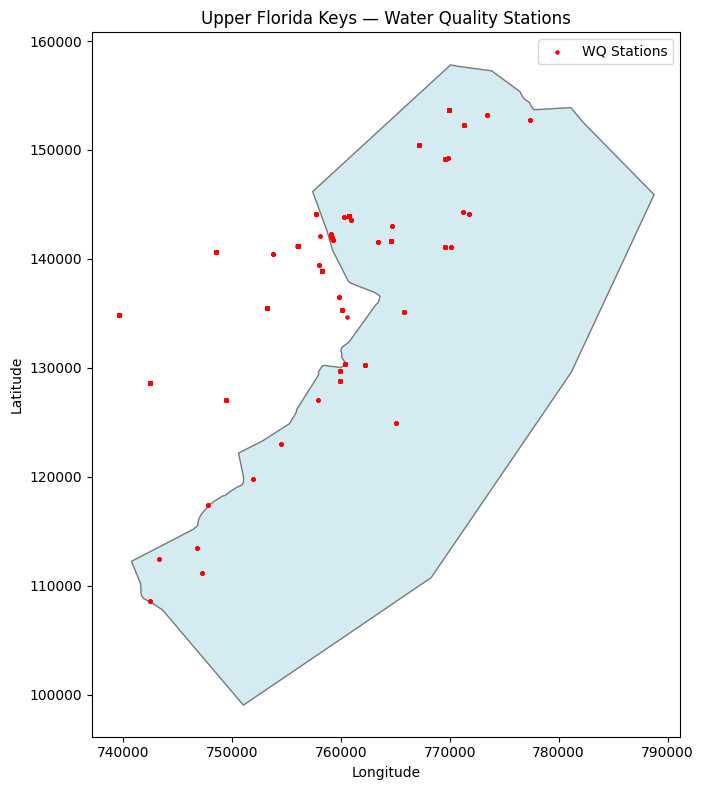

In [150]:
fig, ax = plt.subplots(figsize=(10, 8))

reef_shape.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)
wq_gdf.to_crs(reef_shape.crs).plot(ax=ax, color='red', markersize=5, label='WQ Stations')

plt.title("Upper Florida Keys — Water Quality Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

In [151]:

# Define your parameter columns (adjust names to match yours with units)
param_cols = [col for col in wq_gdf.columns if any(p in col for p in 
              ["Temperature", "Salinity", "Turbidity", "Secchi", "Chlorophyll"])]

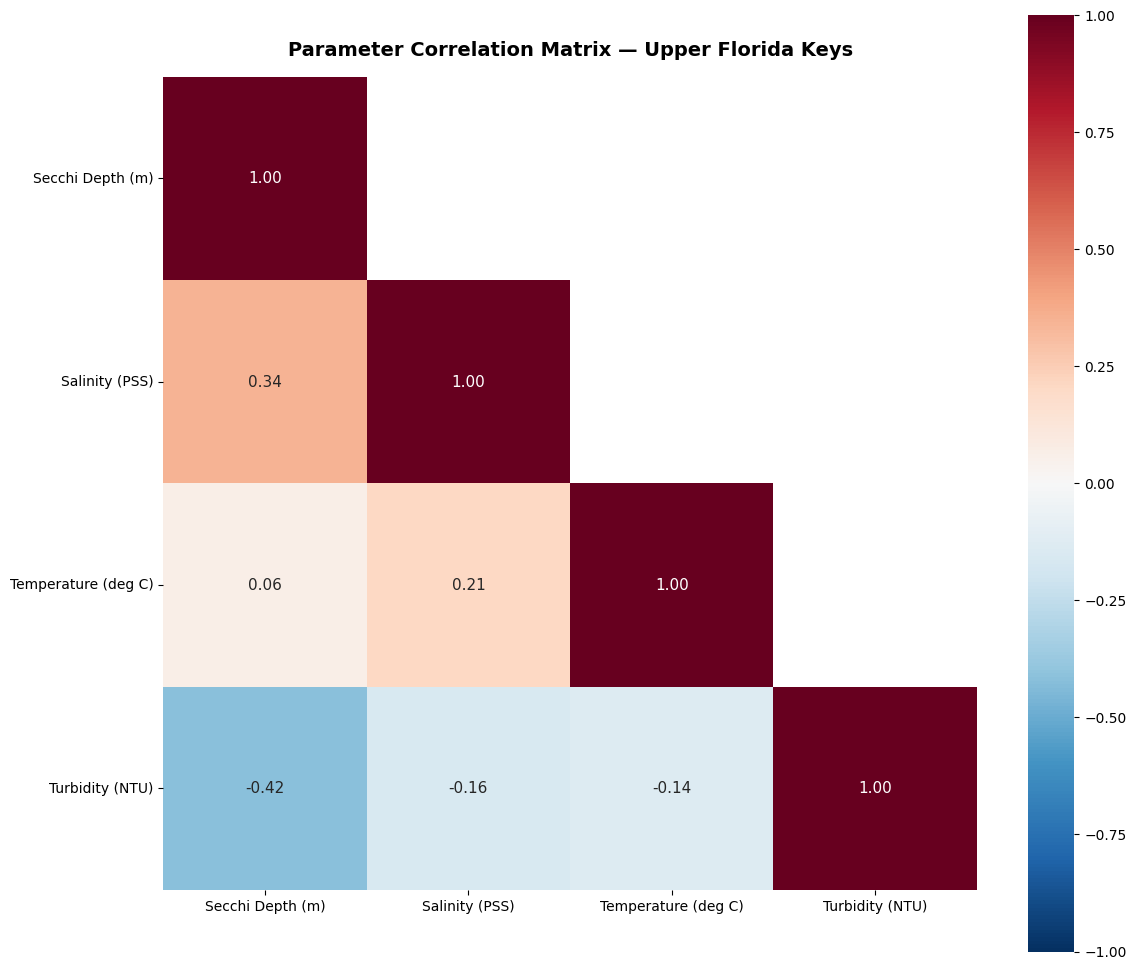

In [152]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = wq_gdf[param_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0,        # no gaps
            square=True,
            annot_kws={"size": 11})

ax.set_title("Parameter Correlation Matrix — Upper Florida Keys", 
             fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)  # horizontal x labels
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

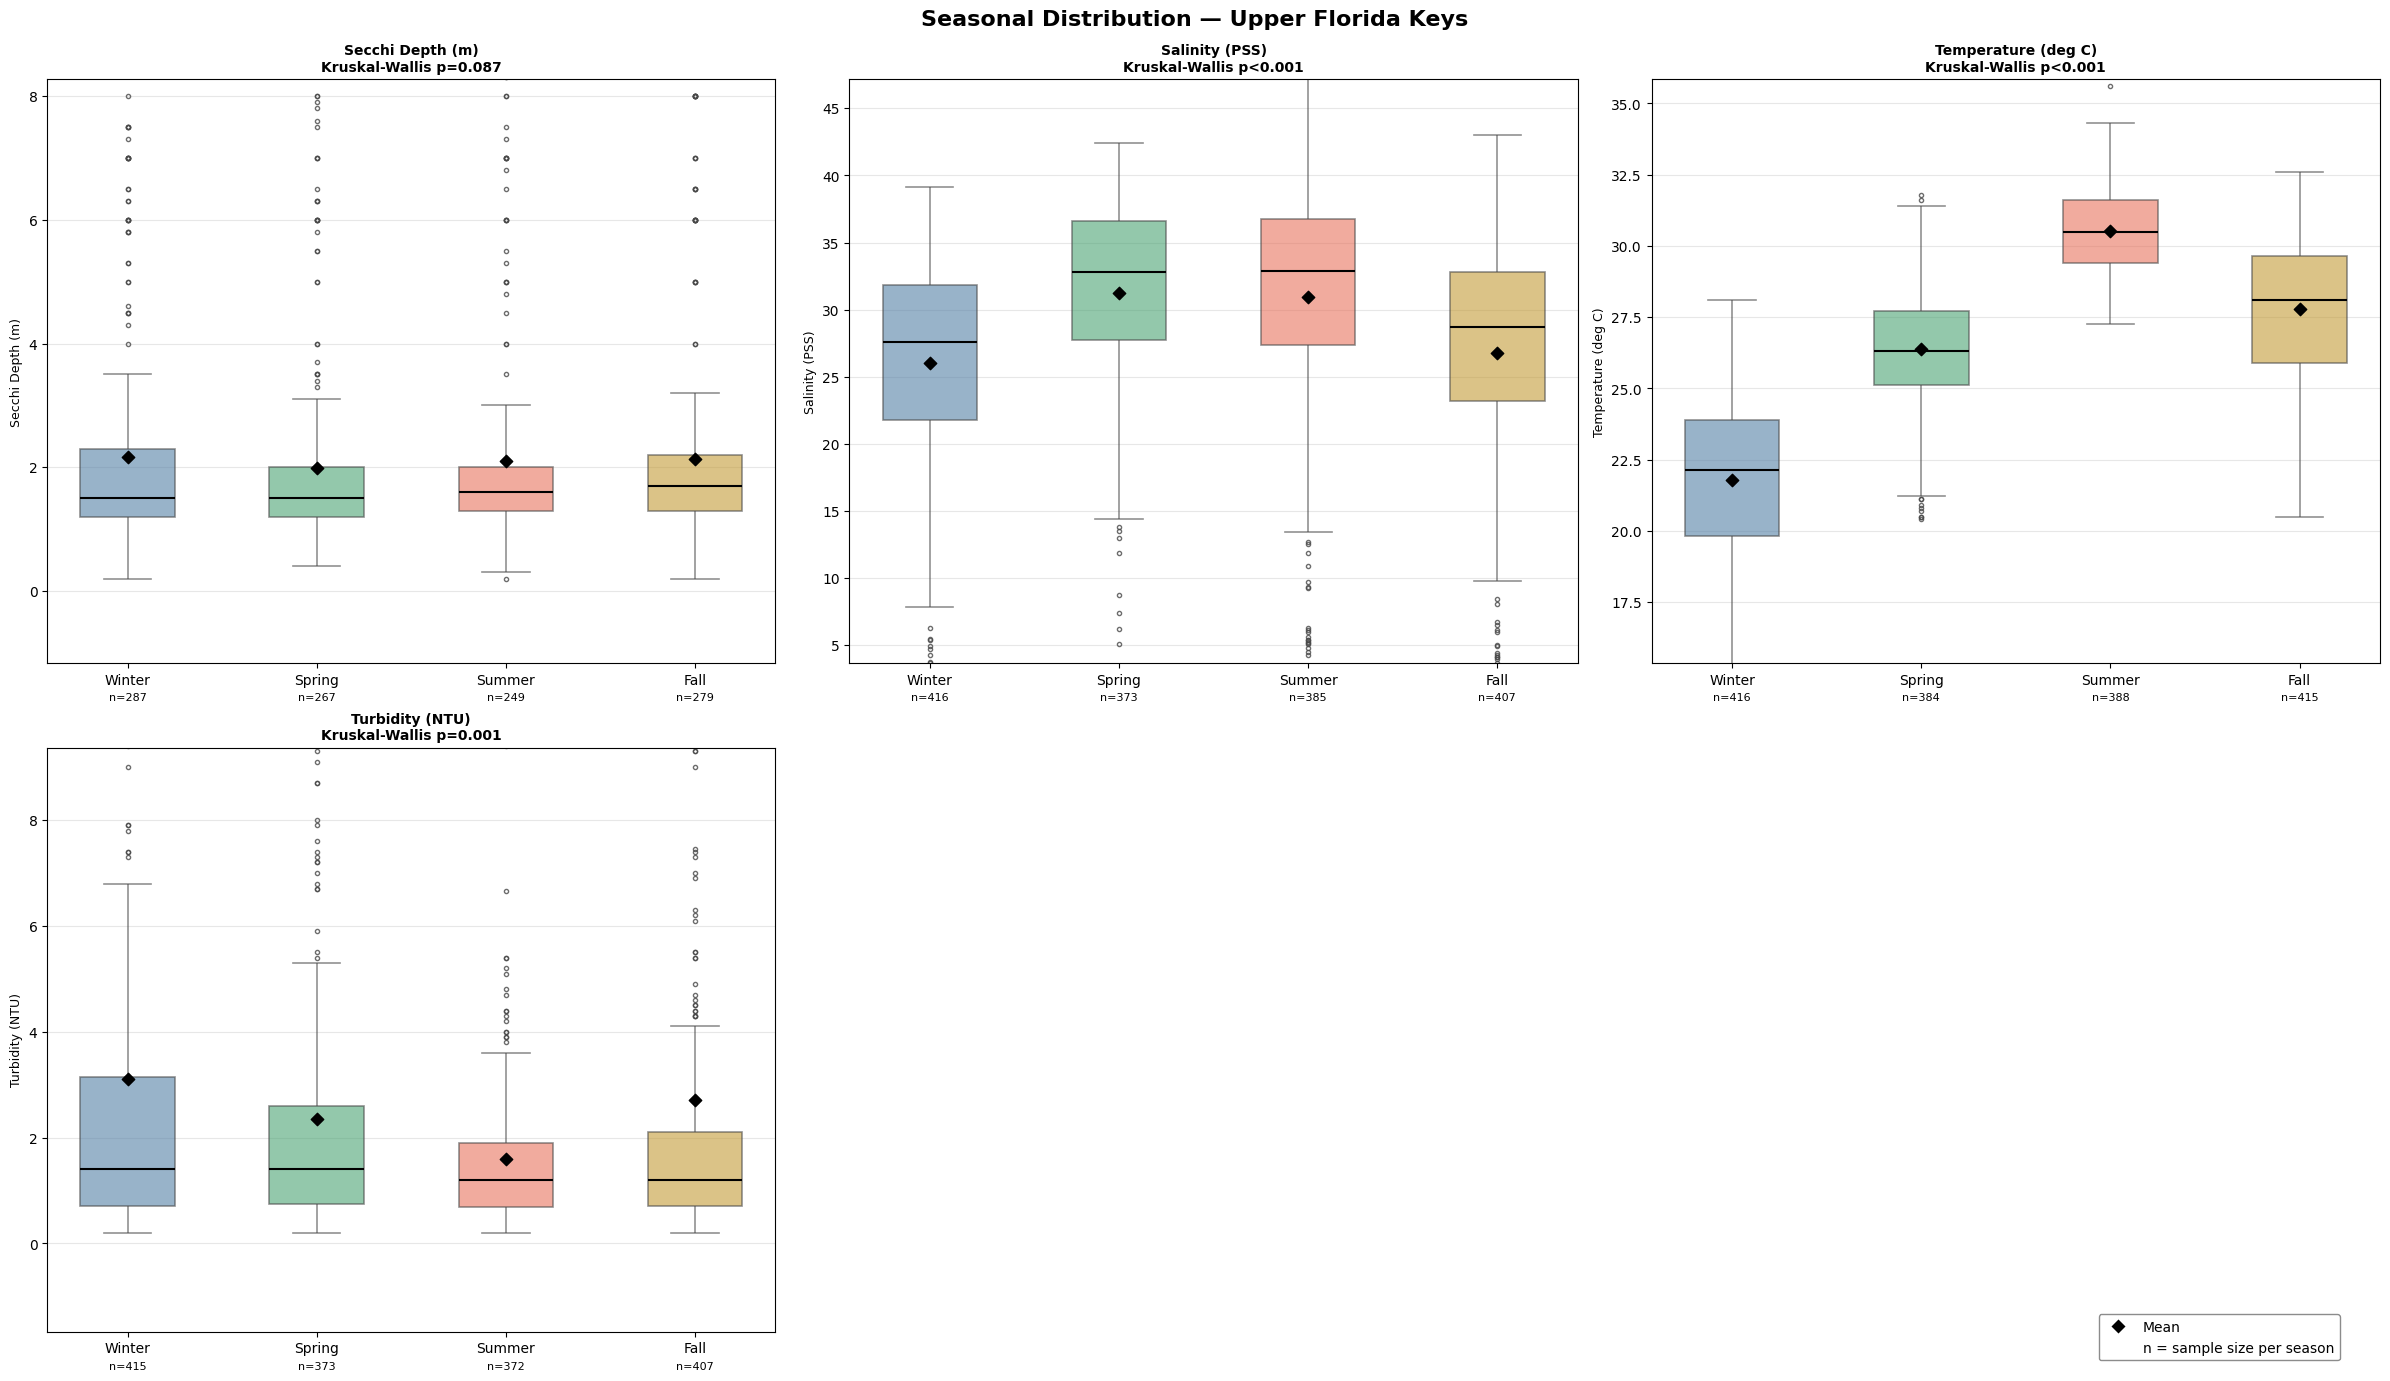

In [153]:
# Seasonal Boxplots (one per parameter)
wq_plot = wq_gdf.reset_index().copy()
wq_plot["Month"] = pd.to_datetime(wq_plot["Date"]).dt.month
wq_plot["Season"] = wq_plot["Month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",   10: "Fall",  11: "Fall"
})

season_order = ["Winter", "Spring", "Summer", "Fall"]
season_palette = {
    "Winter": "steelblue",
    "Spring": "mediumseagreen",
    "Summer": "tomato",
    "Fall":   "goldenrod"
}

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for i, col in enumerate(param_cols):
    ax = axes[i]

    # Boxplot
    sns.boxplot(data=wq_plot, x="Season", y=col, hue="Season",
                order=season_order, palette=season_palette,
                legend=False, ax=ax, width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.8),
                boxprops=dict(alpha=0.6),
                whiskerprops=dict(alpha=0.6),
                capprops=dict(alpha=0.6),
                medianprops=dict(color='black', linewidth=1.5))
    
    # Auto zoom y axis with padding around the data range
    col_data = wq_plot[col].dropna()
    q1 = col_data.quantile(0.05)
    q3 = col_data.quantile(0.95)
    padding = (q3 - q1) * 0.3
    ax.set_ylim(q1 - padding, q3 + padding)

    # Add mean marker
    means = wq_plot.groupby("Season")[col].mean()
    for j, season in enumerate(season_order):
        if season in means:
            ax.scatter(j, means[season], marker='D', color='black',
                      s=40, zorder=5, label='Mean' if j == 0 else "")

    # Add sample size per season
    for j, season in enumerate(season_order):
        n = wq_plot[wq_plot["Season"] == season][col].dropna().shape[0]
        ax.text(j, -0.05, f'n={n}',
                ha='center', va='top', fontsize=8, color='black',
                transform=ax.get_xaxis_transform())

    # Add significance brackets between Winter and Summer
    groups = [wq_plot[wq_plot["Season"] == s][col].dropna() for s in season_order]
    _, p_val = stats.kruskal(*[g for g in groups if len(g) > 0])
    p_str = "p<0.001" if p_val < 0.001 else f"p={p_val:.3f}"
    ax.set_title(f"{col}\nKruskal-Wallis {p_str}", fontsize=10, fontweight="bold")

    ax.set_xlabel("")
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Seasonal Distribution — Upper Florida Keys", fontsize=16, fontweight="bold")

# Build shared legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
           markersize=8, label='Mean'),
    Line2D([0], [0], color='none', label='n = sample size per season')
]

fig.legend(handles=legend_elements, loc='lower right',
           bbox_to_anchor=(0.98, 0.01), fontsize=10,
           frameon=True, framealpha=0.9, edgecolor='gray')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("seasonal_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

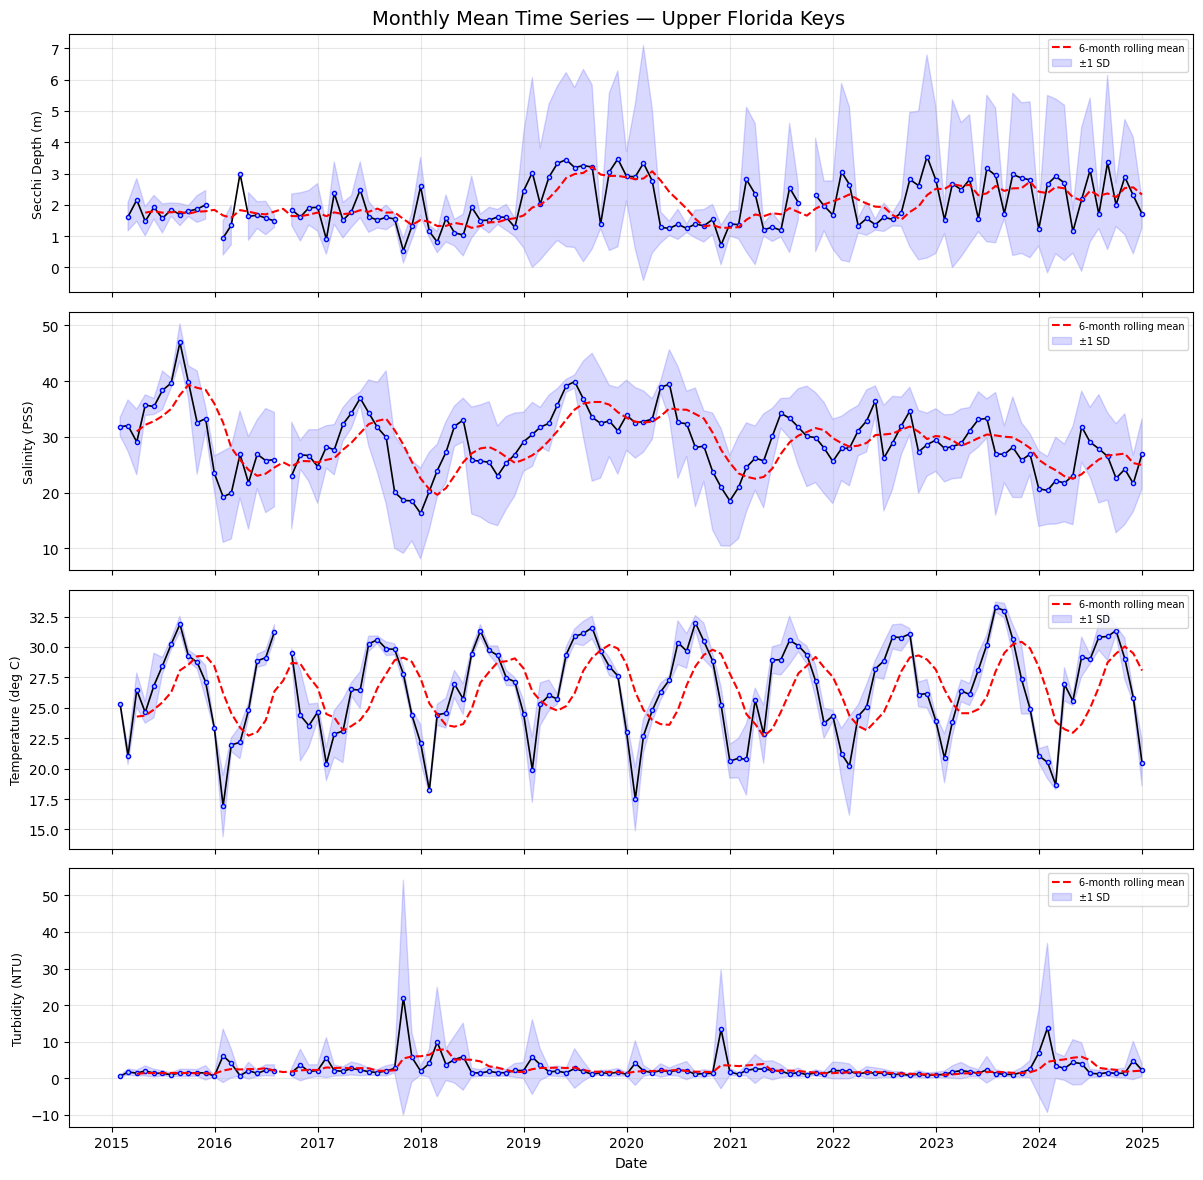

In [154]:
# Time Series (monthly mean per parameter)
fig, axes = plt.subplots(len(param_cols), 1, figsize=(12, 3 * len(param_cols)), sharex=True)

for i, col in enumerate(param_cols):
    # Compute mean and std from the same resampling operation
    monthly_mean = wq_gdf[col].resample("ME").mean()
    monthly_std  = wq_gdf[col].resample("ME").std()

    axes[i].plot(monthly_mean.index, monthly_mean, linewidth=1.2, 
                 color='black', marker='o', markersize=3, markerfacecolor='lightblue',
                 markeredgecolor='blue')
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(True, alpha=0.3)
    
    # Add a rolling 6-month mean to show trend
    rolling = monthly_mean.rolling(window=6, min_periods=3).mean()
    axes[i].plot(monthly_mean.index, rolling, linewidth=1.5, 
                 color='red', linestyle='--', label='6-month rolling mean')
    
    # Shade ± 1 standard deviation band
    axes[i].fill_between(monthly_mean.index, 
                          monthly_mean - monthly_std, 
                          monthly_mean + monthly_std,
                          alpha=0.15, color='blue', label='±1 SD')
    
    axes[i].legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel("Date")
fig.suptitle("Monthly Mean Time Series — Upper Florida Keys", fontsize=14)
plt.tight_layout()
plt.savefig("time_series.png", dpi=150)
plt.show()

# For SD bands: 
# Narrow band — readings were consistent that month across stations and time, conditions were stable
# Wide band — high variability, meaning either different stations had very different readings, or conditions fluctuated a lot within the month

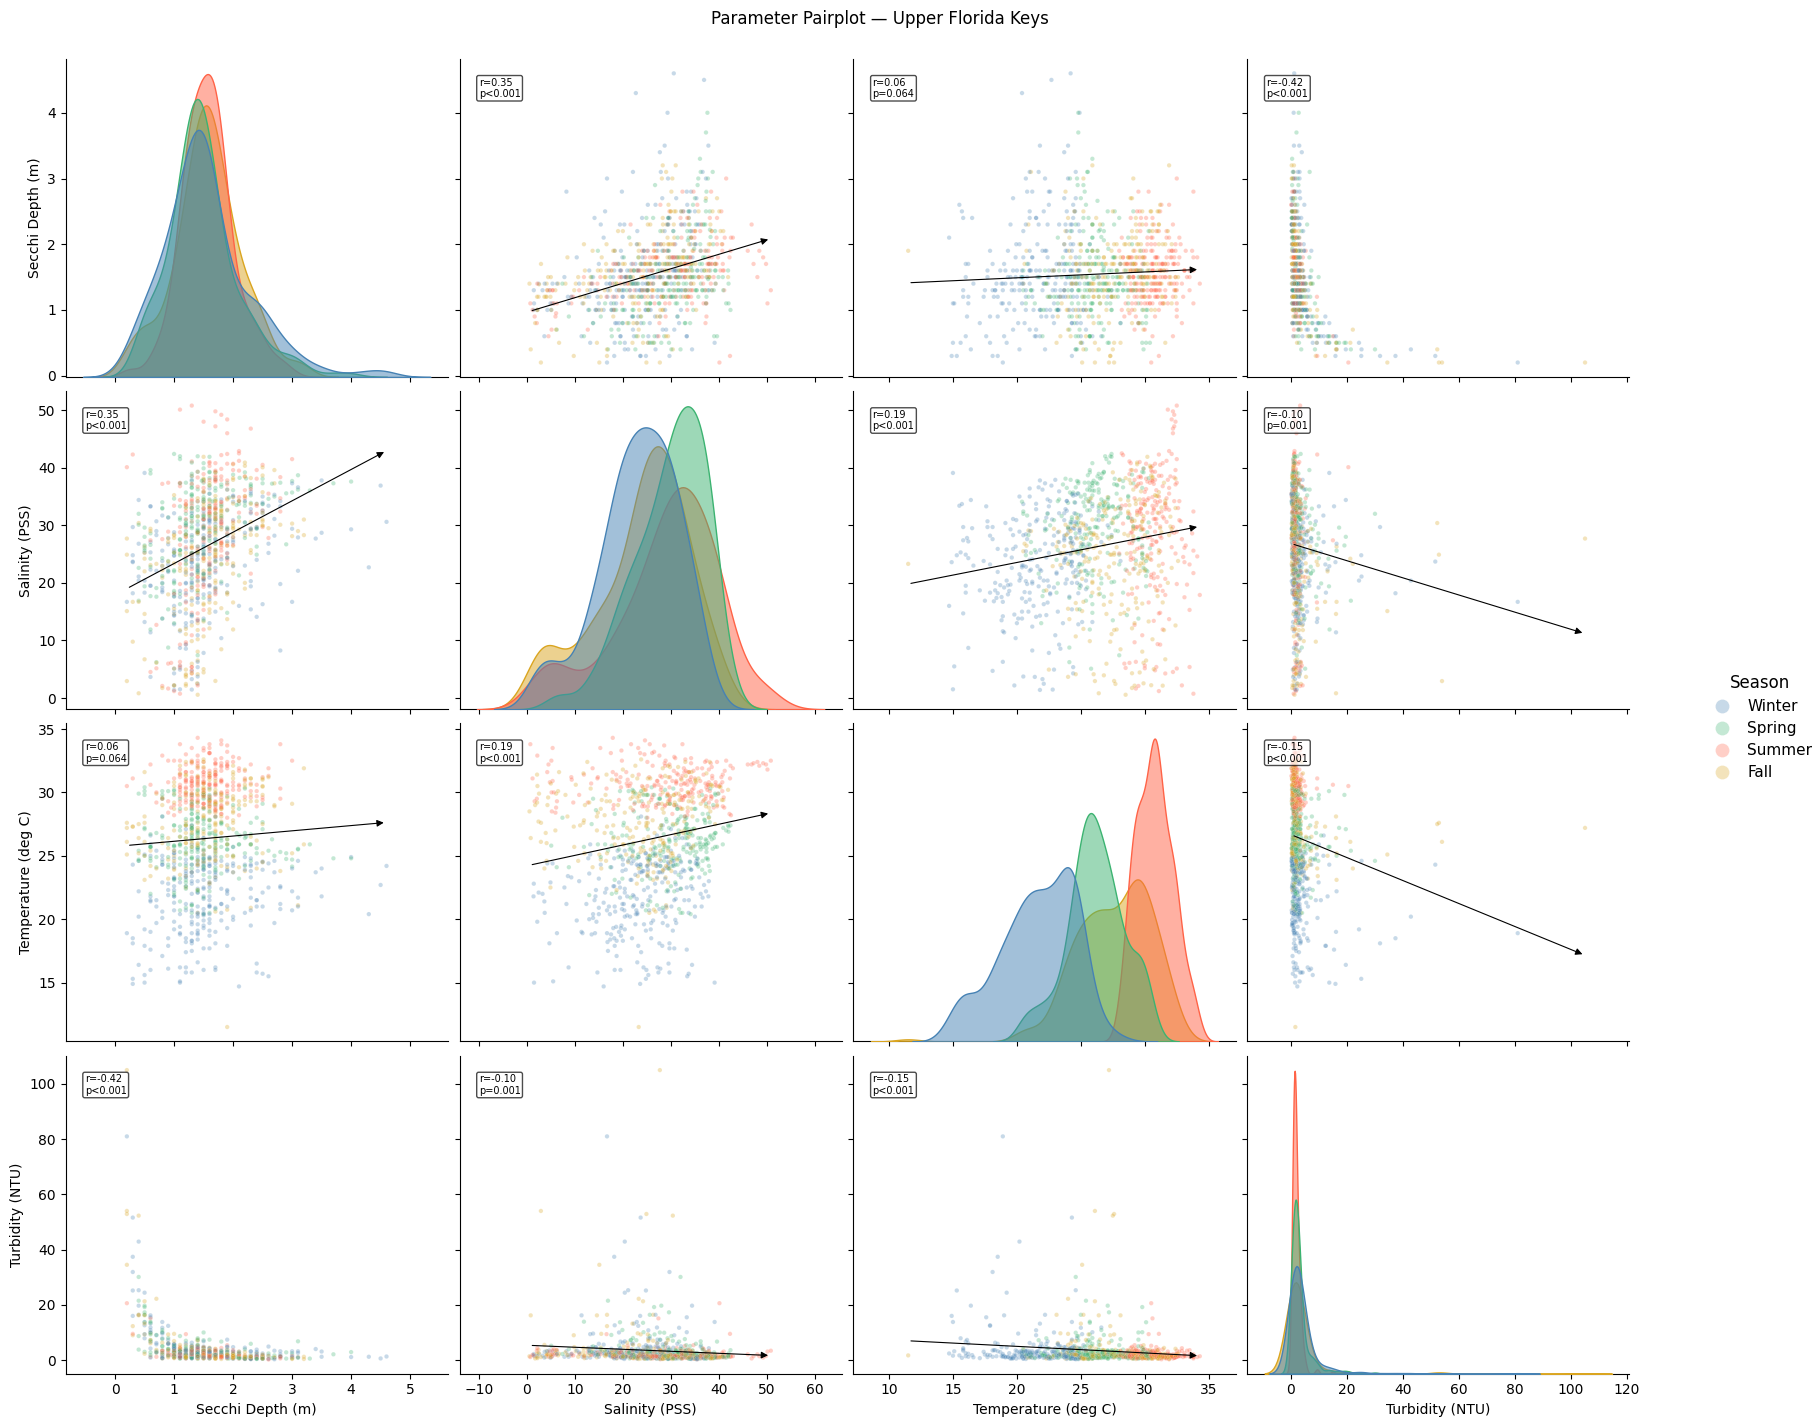

In [155]:
# Pairplot (relationships between all parameters)
pair_data = wq_gdf[param_cols].dropna().reset_index(drop=True)

# Add season for color coding
pair_data["Season"] = pd.to_datetime(wq_gdf[param_cols].dropna().index).month.map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",   10: "Fall",  11: "Fall"
})

season_palette = {
    "Winter": "steelblue",
    "Spring": "mediumseagreen",
    "Summer": "tomato",
    "Fall":   "goldenrod"
}

# Pairplot colored by season
g = sns.pairplot(pair_data, hue="Season", palette=season_palette,
                 diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10},
                 diag_kws={"alpha": 0.5},
                 height=3.5, aspect=1.2)

# Add correlation coefficients and regression lines to off-diagonal plots
for i, row_col in enumerate(param_cols):
    for j, col_col in enumerate(param_cols):
        if i == j:
            continue
        ax = g.axes[i, j]

        # Get clean paired data for these two columns
        paired = pair_data[[row_col, col_col]].dropna()
        if len(paired) < 5:
            continue

        x = paired[col_col]
        y = paired[row_col]

        # Regression line with arrow
        slope, intercept, r, p, _ = stats.linregress(x, y)
        x_start = x.min()
        x_end   = x.max()
        y_start = slope * x_start + intercept
        y_end   = slope * x_end   + intercept

        ax.annotate("",
                    xy=(x_end, y_end),
                    xytext=(x_start, y_start),
                    arrowprops=dict(
                        arrowstyle="-|>",
                        color="black",
                        lw=0.8,
                    ))

        # Correlation coefficient and p-value
        p_str = "p<0.001" if p < 0.001 else f"p={p:.3f}"
        ax.annotate(f"r={r:.2f}\n{p_str}",
                    xy=(0.05, 0.88), xycoords='axes fraction',
                    fontsize=7, color='black',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Move and resize legend
g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_title("Season")
for text in g._legend.get_texts():
    text.set_fontsize(11)
g._legend.get_title().set_fontsize(12)
for handle in g._legend.legend_handles:
    handle.set_markersize(10)

g.fig.suptitle("Parameter Pairplot — Upper Florida Keys", y=1.02)
plt.savefig("pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [156]:
# pip install contextily

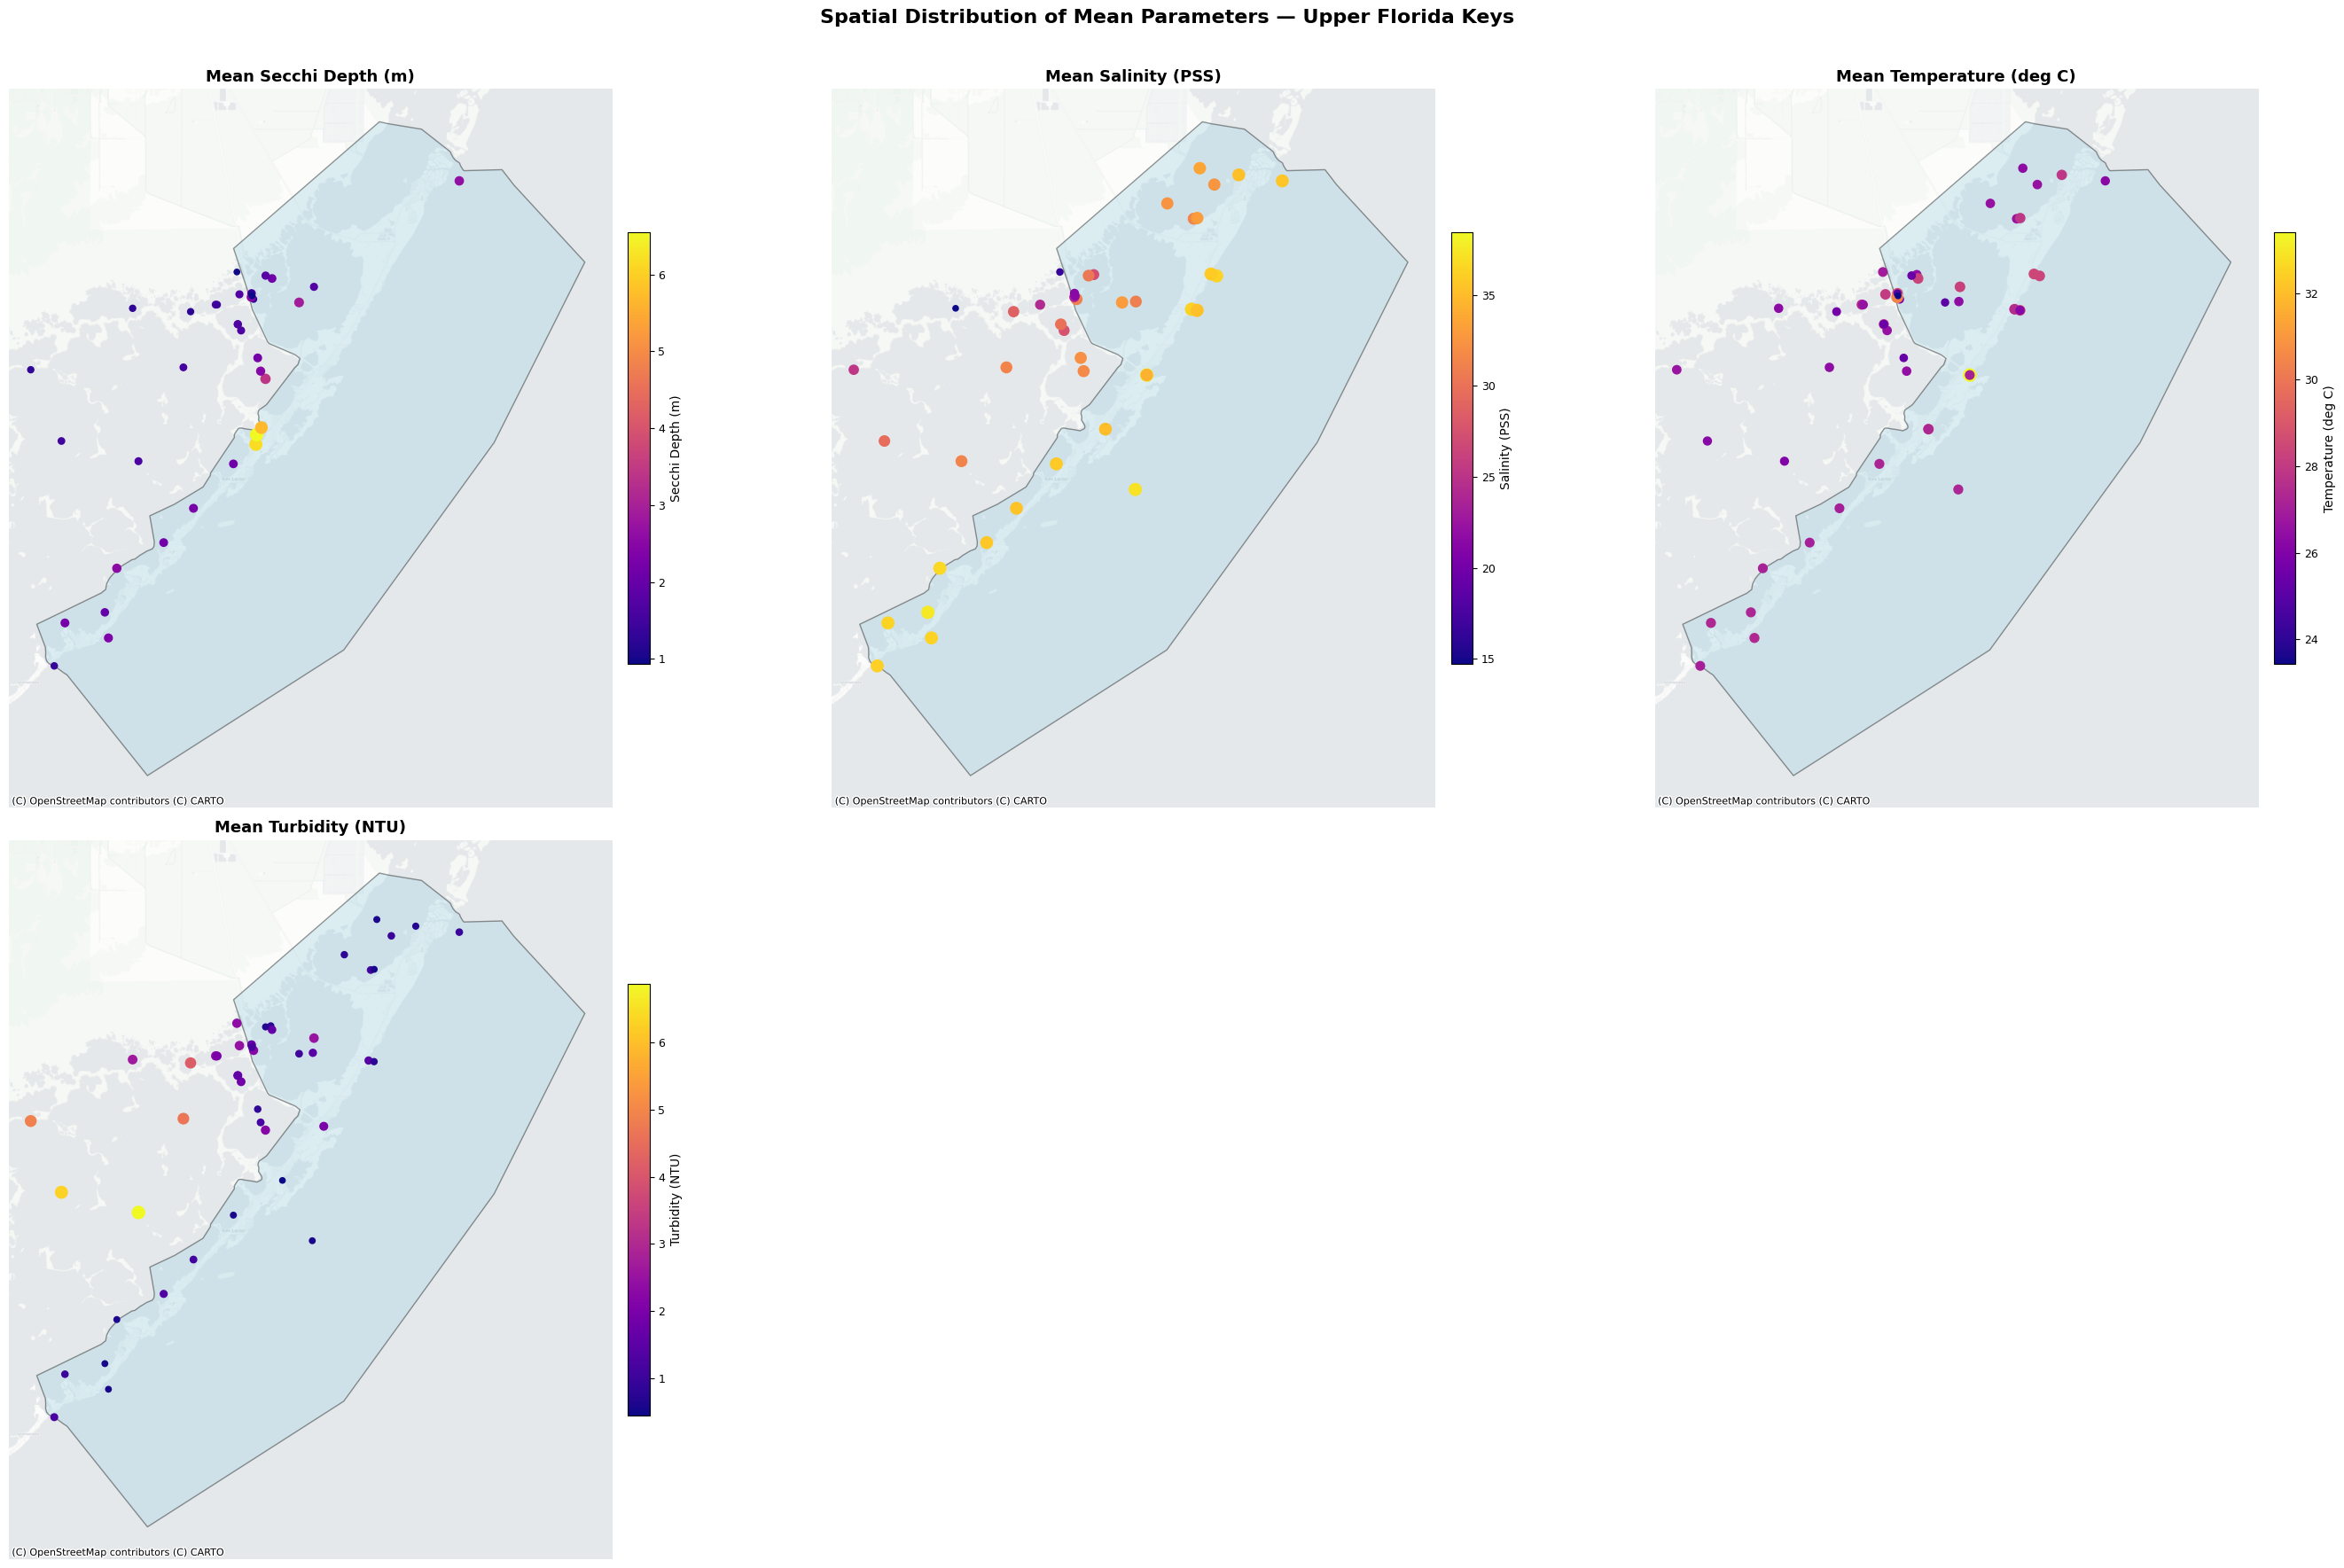

In [157]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx

station_means = wq_gdf.groupby("MonitoringLocationIdentifier")[param_cols].mean()
wq_stations = wq_gdf.dissolve(by="MonitoringLocationIdentifier")[["geometry"]].join(station_means)

# Reproject to Web Mercator for basemap compatibility
reef_wm     = reef_shape.to_crs(epsg=3857)
stations_wm = wq_stations.to_crs(epsg=3857)

fig, axes = plt.subplots(2, 3, figsize=(28, 18))
axes = axes.flatten()

for i, col in enumerate(param_cols):
    ax = axes[i]

    # Plot shapefile FIRST to set axes extent
    reef_wm.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.4, zorder=1)

    # Add basemap using explicit CRS
    try:
        ctx.add_basemap(ax, crs=stations_wm.crs,
                        source=ctx.providers.CartoDB.Positron,
                        alpha=0.6, zorder=0, zoom=12)
    except Exception as e:
        print(f"Basemap error: {e}")
        pass

    # Scale marker size to value
    values = stations_wm[col].dropna()
    scaled_sizes = ((values - values.min()) / (values.max() - values.min()) * 80) + 20

    # Plot stations
    stations_wm.dropna(subset=[col]).plot(
        ax=ax, column=col, cmap="plasma",
        markersize=scaled_sizes,
        legend=False,
        zorder=3
    )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap="plasma",
                                norm=plt.Normalize(vmin=values.min(), vmax=values.max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label(col, fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    ax.set_title(f"Mean {col}", fontsize=13, fontweight="bold")
    ax.axis("off")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Spatial Distribution of Mean Parameters — Upper Florida Keys",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("spatial_means.png", dpi=150, bbox_inches="tight")
plt.show()